<a href="https://colab.research.google.com/github/Abhiyuday07/Crop-Recommendation-Data-Science-Project/blob/main/Crop_Recommendation_using_kaggle_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import kagglehub
path = kagglehub.dataset_download("atharvaingle/crop-recommendation-dataset")

Using Colab cache for faster access to the 'crop-recommendation-dataset' dataset.


In [7]:
import os
os.listdir(path)

['Crop_recommendation.csv']

In [8]:
import pandas as pd
df3=pd.read_csv(path+'/Crop_recommendation.csv')

In [9]:
df3

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice
...,...,...,...,...,...,...,...,...
2195,107,34,32,26.774637,66.413269,6.780064,177.774507,coffee
2196,99,15,27,27.417112,56.636362,6.086922,127.924610,coffee
2197,118,33,30,24.131797,67.225123,6.362608,173.322839,coffee
2198,117,32,34,26.272418,52.127394,6.758793,127.175293,coffee


In [10]:
df3.shape

(2200, 8)

Let's examine the columns of `df3` to find the temperature data.

In [11]:
print(df3.columns)

Index(['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'label'], dtype='object')


In [12]:
average_temperature = df3['temperature'].mean()
print(f"The average temperature in df3 is: {average_temperature:.2f}")

The average temperature in df3 is: 25.62


In [13]:
df3.groupby('label')['temperature'].mean()

,temperature
label,
apple,22.630942
banana,27.376798
blackgram,29.973340
chickpea,18.872847
coconut,27.409892
coffee,25.540477
cotton,23.988958
grapes,23.849575
jute,24.958376


In [14]:
tcl=df3.groupby('label')['temperature'].mean()

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

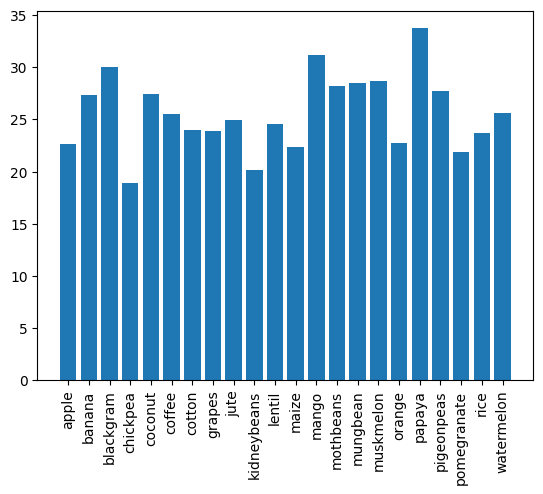

In [16]:
plt.bar(tcl.index,tcl.values)
plt.xticks(rotation=90)
plt.show()

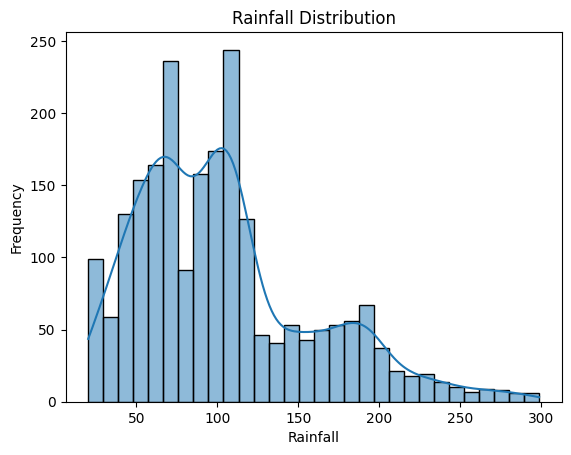

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(data=df3, x='rainfall', bins=30, kde=True)

plt.title('Rainfall Distribution')
plt.xlabel('Rainfall')
plt.ylabel('Frequency')

plt.show()

In [20]:
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

In [22]:
df3.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [24]:
df3.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [25]:
df3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB


In [26]:
df3.describe()

,N,P,K,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


In [27]:
df3.isnull().sum()

,0
N,0
P,0
K,0
temperature,0
humidity,0
ph,0
rainfall,0
label,0


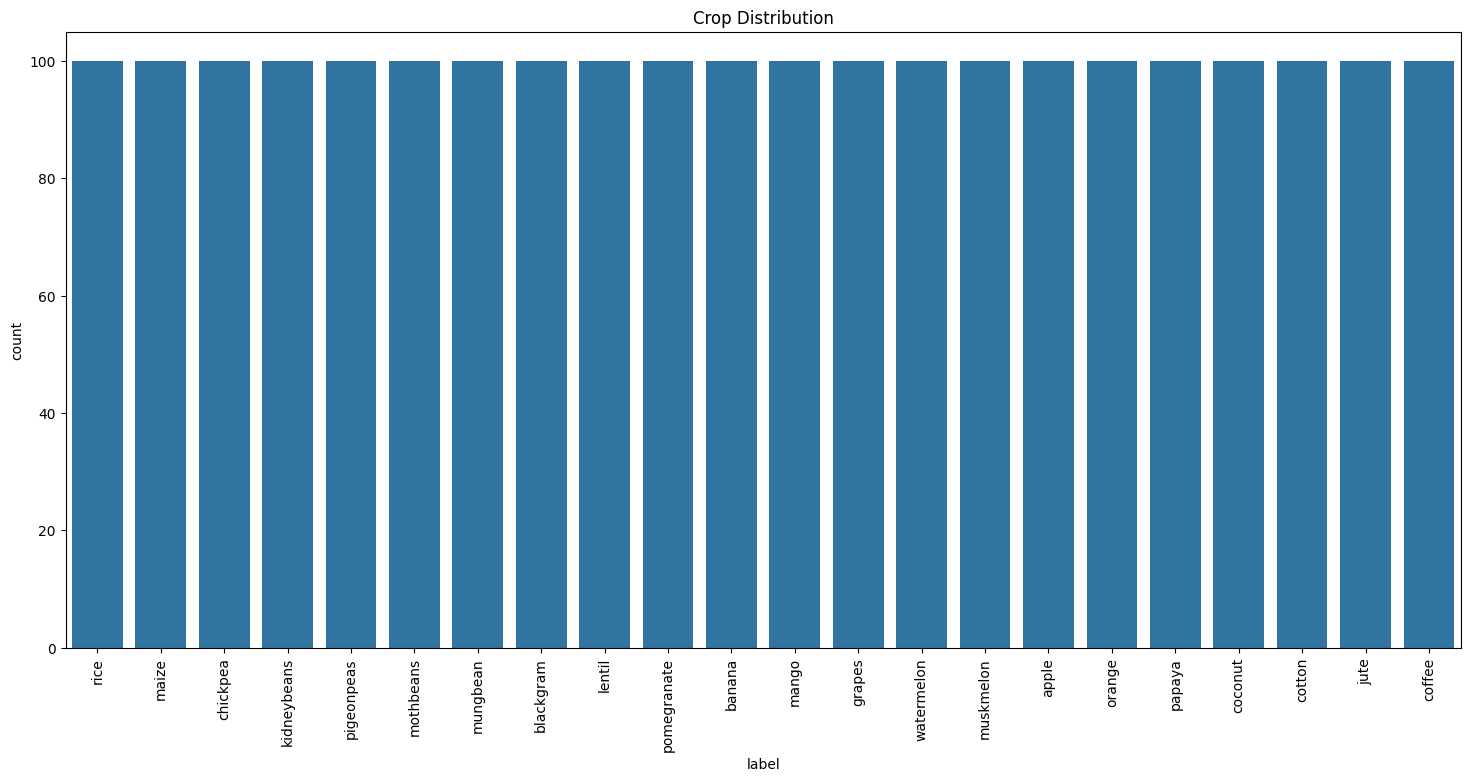

In [28]:
plt.figure(figsize=(18,8))
sns.countplot(x='label', data=df3)
plt.xticks(rotation=90)
plt.title('Crop Distribution')
plt.show()

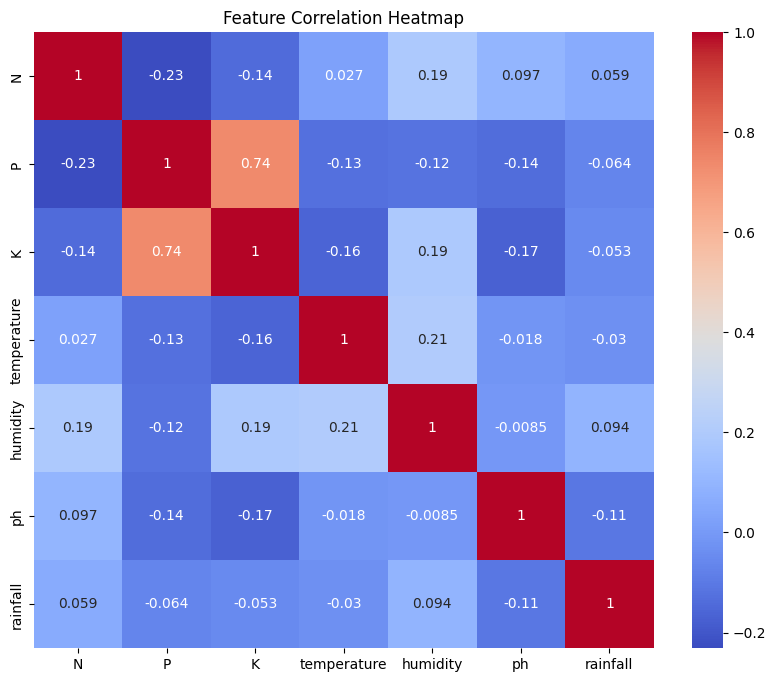

In [29]:
plt.figure(figsize=(10,8))
sns.heatmap(df3.drop('label', axis=1).corr(), annot=True, cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()

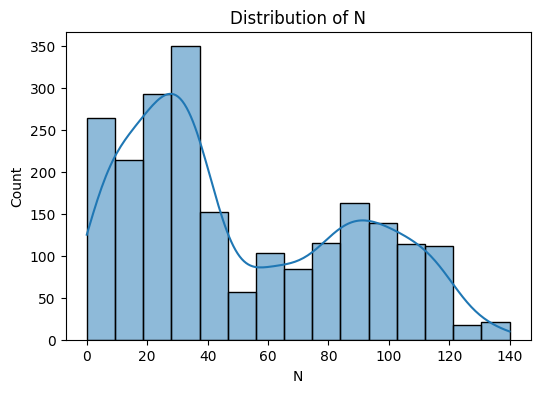

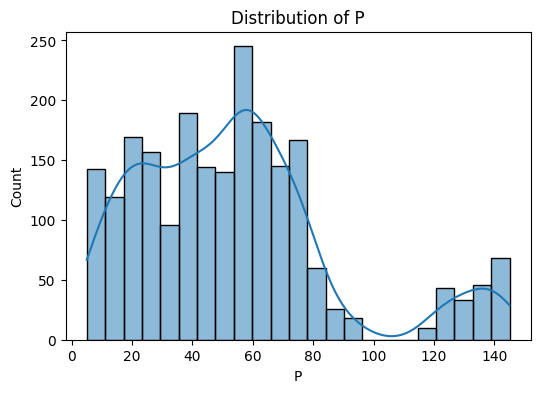

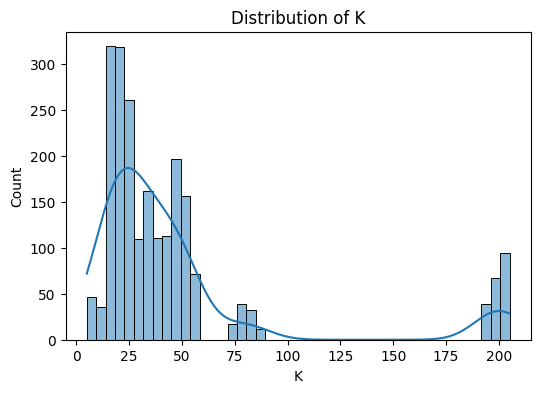

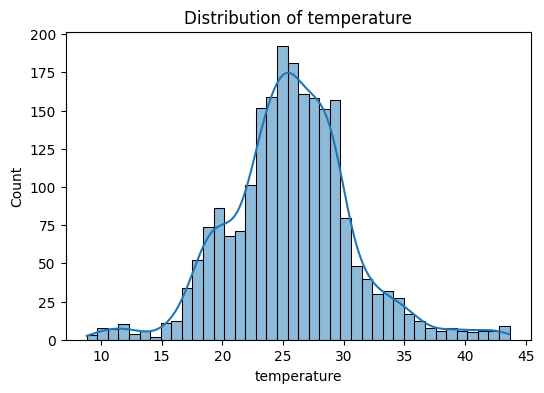

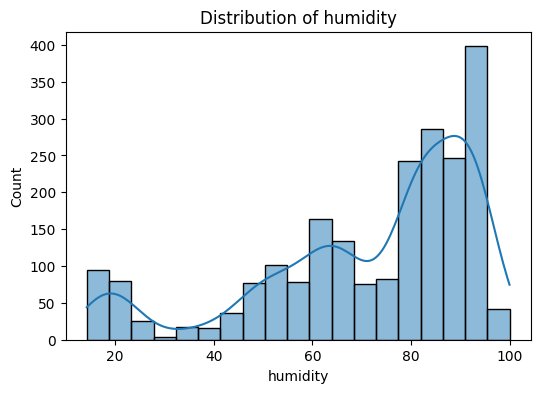

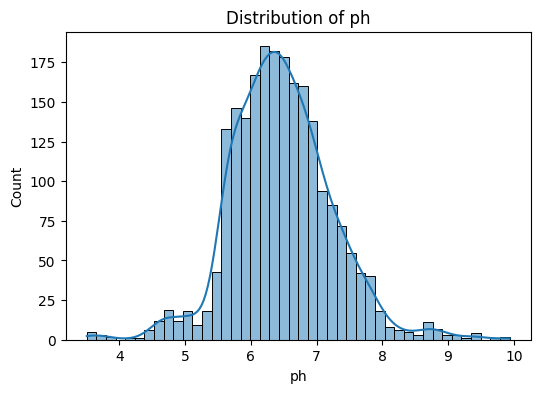

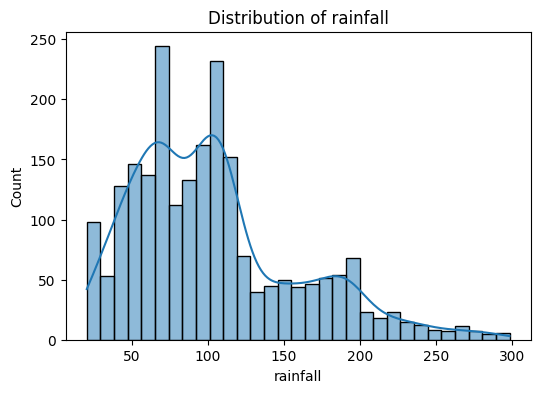

In [31]:
features = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']

for feature in features:
    plt.figure(figsize=(6,4))
    sns.histplot(df3[feature], kde=True)
    plt.title(f'Distribution of {feature}')
    plt.show()

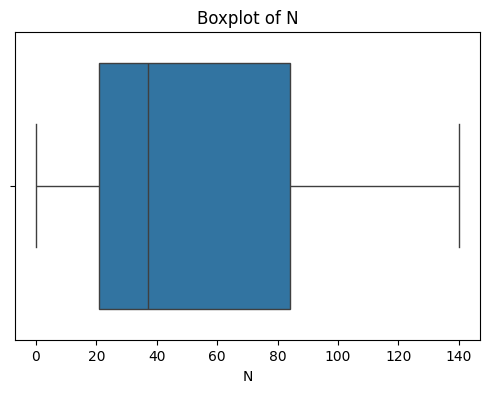

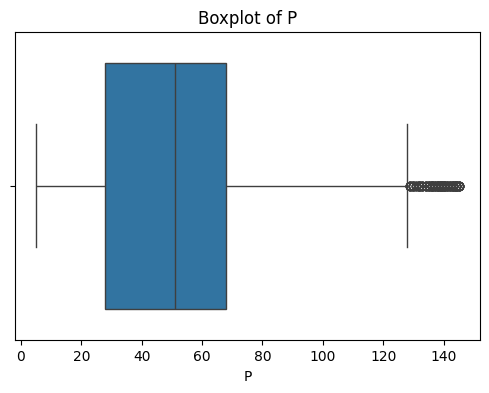

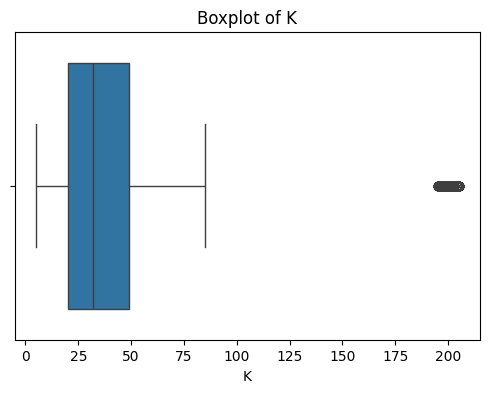

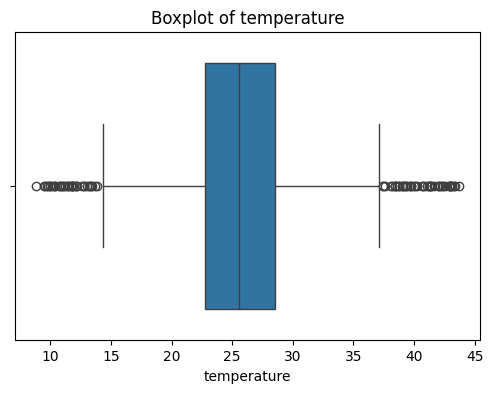

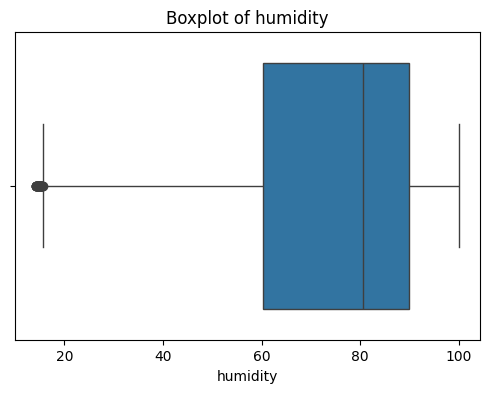

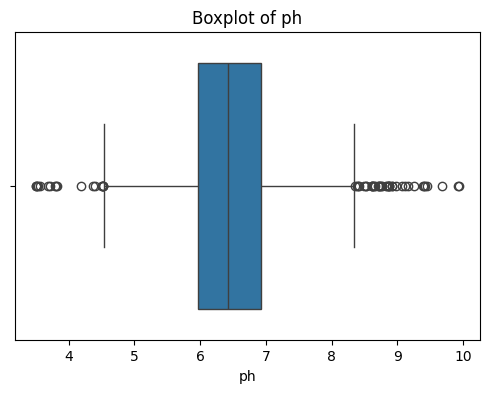

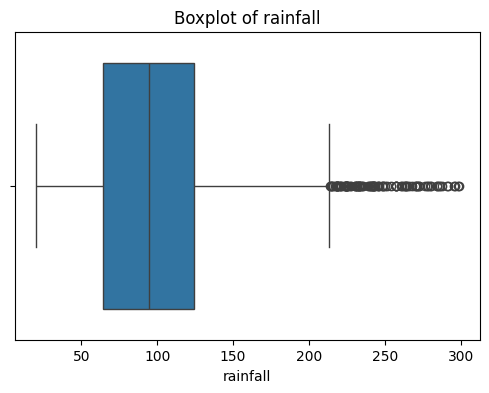

In [32]:
for feature in features:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df3[feature])
    plt.title(f'Boxplot of {feature}')
    plt.show()

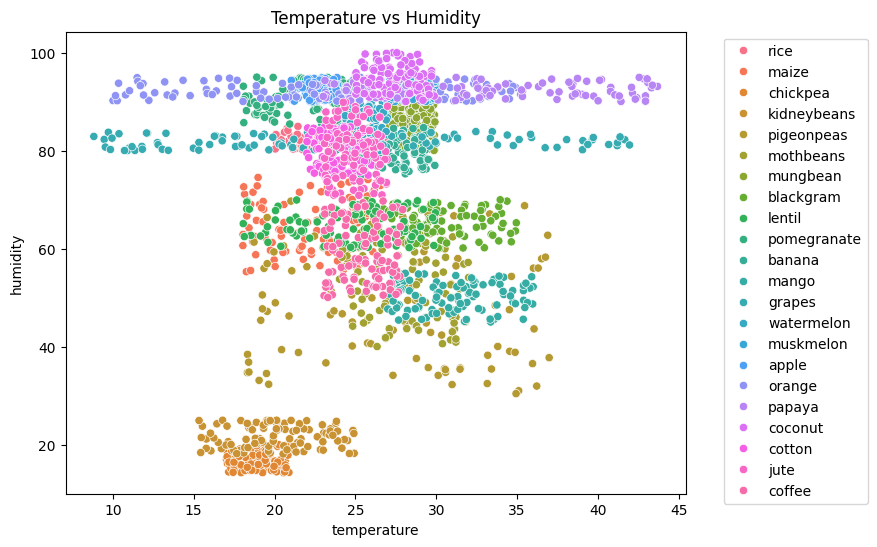

In [33]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='temperature', y='humidity', hue='label', data=df3)
plt.title('Temperature vs Humidity')
plt.legend(bbox_to_anchor=(1.05,1), loc='upper left')
plt.show()

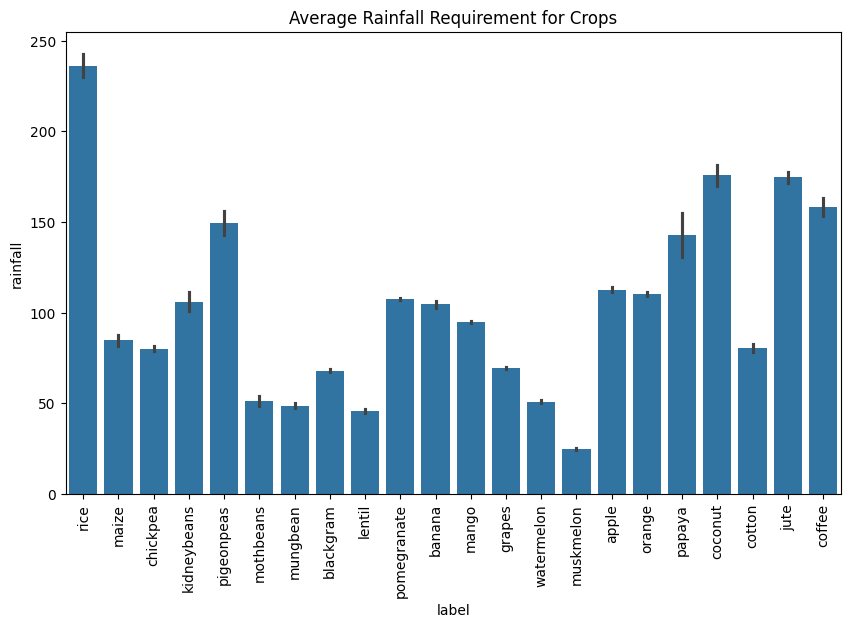

In [34]:
plt.figure(figsize=(10,6))
sns.barplot(x='label', y='rainfall', data=df3)
plt.xticks(rotation=90)
plt.title('Average Rainfall Requirement for Crops')
plt.show()

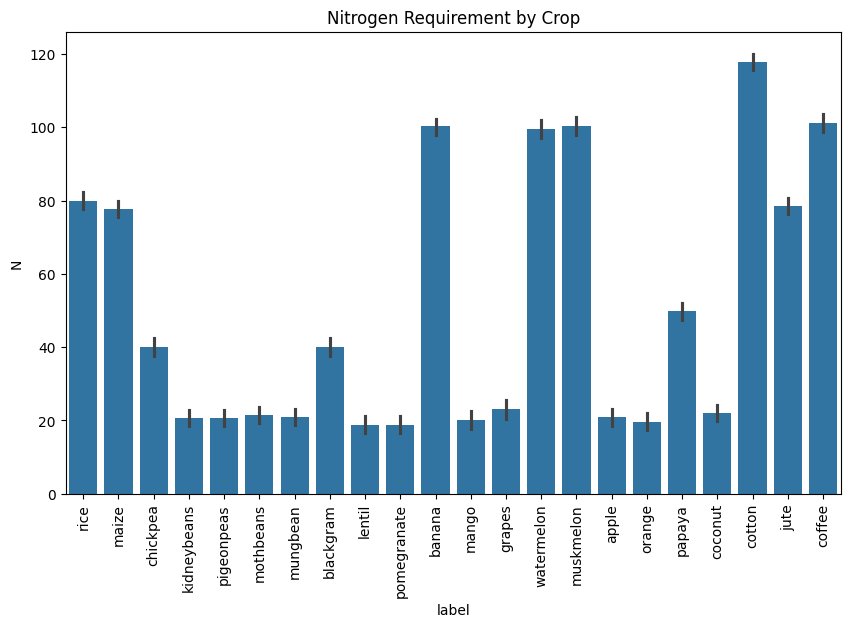

In [35]:
plt.figure(figsize=(10,6))
sns.barplot(x='label', y='N', data=df3)
plt.xticks(rotation=90)
plt.title('Nitrogen Requirement by Crop')
plt.show()

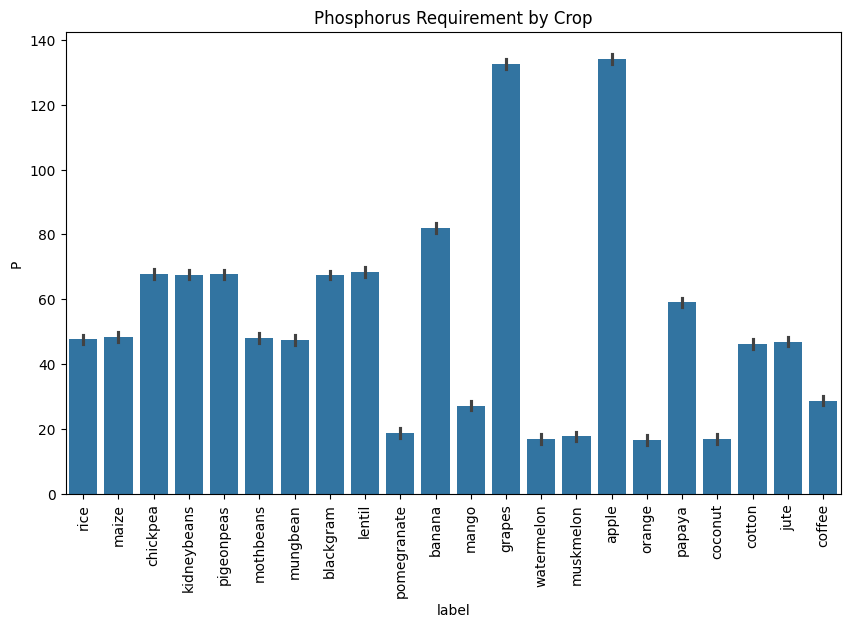

In [36]:
plt.figure(figsize=(10,6))
sns.barplot(x='label', y='P', data=df3)
plt.xticks(rotation=90)
plt.title('Phosphorus Requirement by Crop')
plt.show()

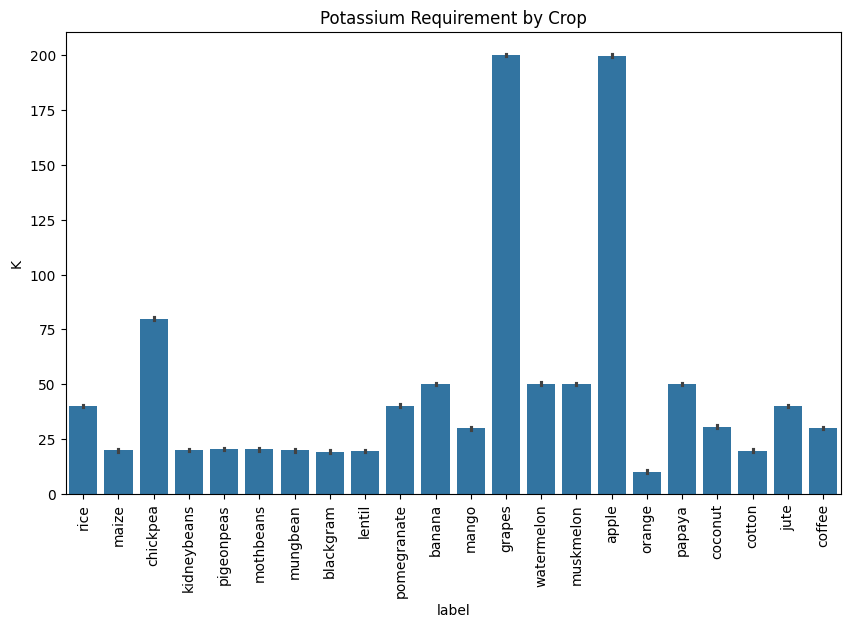

In [37]:
plt.figure(figsize=(10,6))
sns.barplot(x='label', y='K', data=df3)
plt.xticks(rotation=90)
plt.title('Potassium Requirement by Crop')
plt.show()

In [39]:
le = LabelEncoder()
df3['label_encoded'] = le.fit_transform(df3['label'])

In [40]:
X = df3.drop(['label', 'label_encoded'], axis=1)
y = df3['label_encoded']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [41]:
model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

In [42]:
y_pred = model.predict(X_test)

In [43]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.9931818181818182


In [44]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        23
           1       1.00      1.00      1.00        21
           2       1.00      1.00      1.00        20
           3       1.00      1.00      1.00        26
           4       1.00      1.00      1.00        27
           5       1.00      1.00      1.00        17
           6       1.00      1.00      1.00        17
           7       1.00      1.00      1.00        14
           8       0.92      1.00      0.96        23
           9       1.00      1.00      1.00        20
          10       0.92      1.00      0.96        11
          11       1.00      1.00      1.00        21
          12       1.00      1.00      1.00        19
          13       1.00      0.96      0.98        24
          14       1.00      1.00      1.00        19
          15       1.00      1.00      1.00        17
          16       1.00      1.00      1.00        14
          17       1.00    

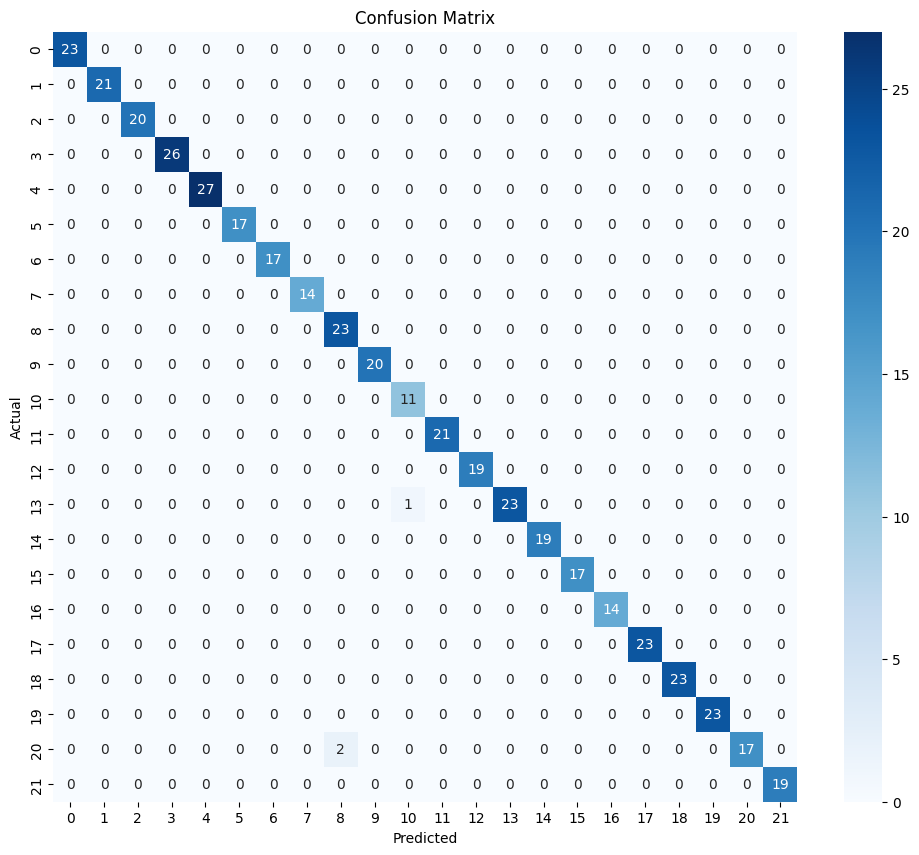

In [45]:
plt.figure(figsize=(12,10))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

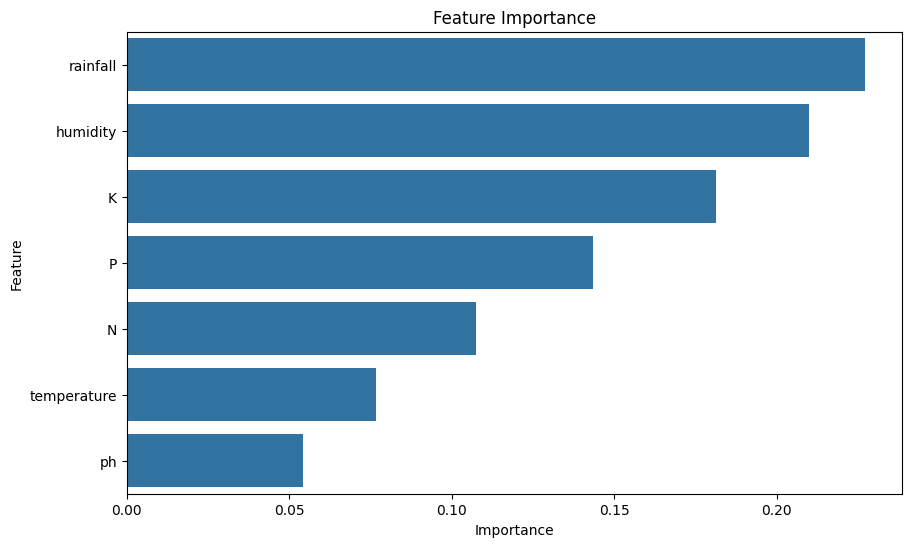

In [46]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

importance = importance.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=importance)
plt.title('Feature Importance')
plt.show()

In [47]:
sample_data = [[90, 42, 43, 20.8, 82.0, 6.5, 202.9]]

prediction = model.predict(sample_data)

crop_name = le.inverse_transform(prediction)

print("Recommended Crop:", crop_name[0])

Recommended Crop: rice


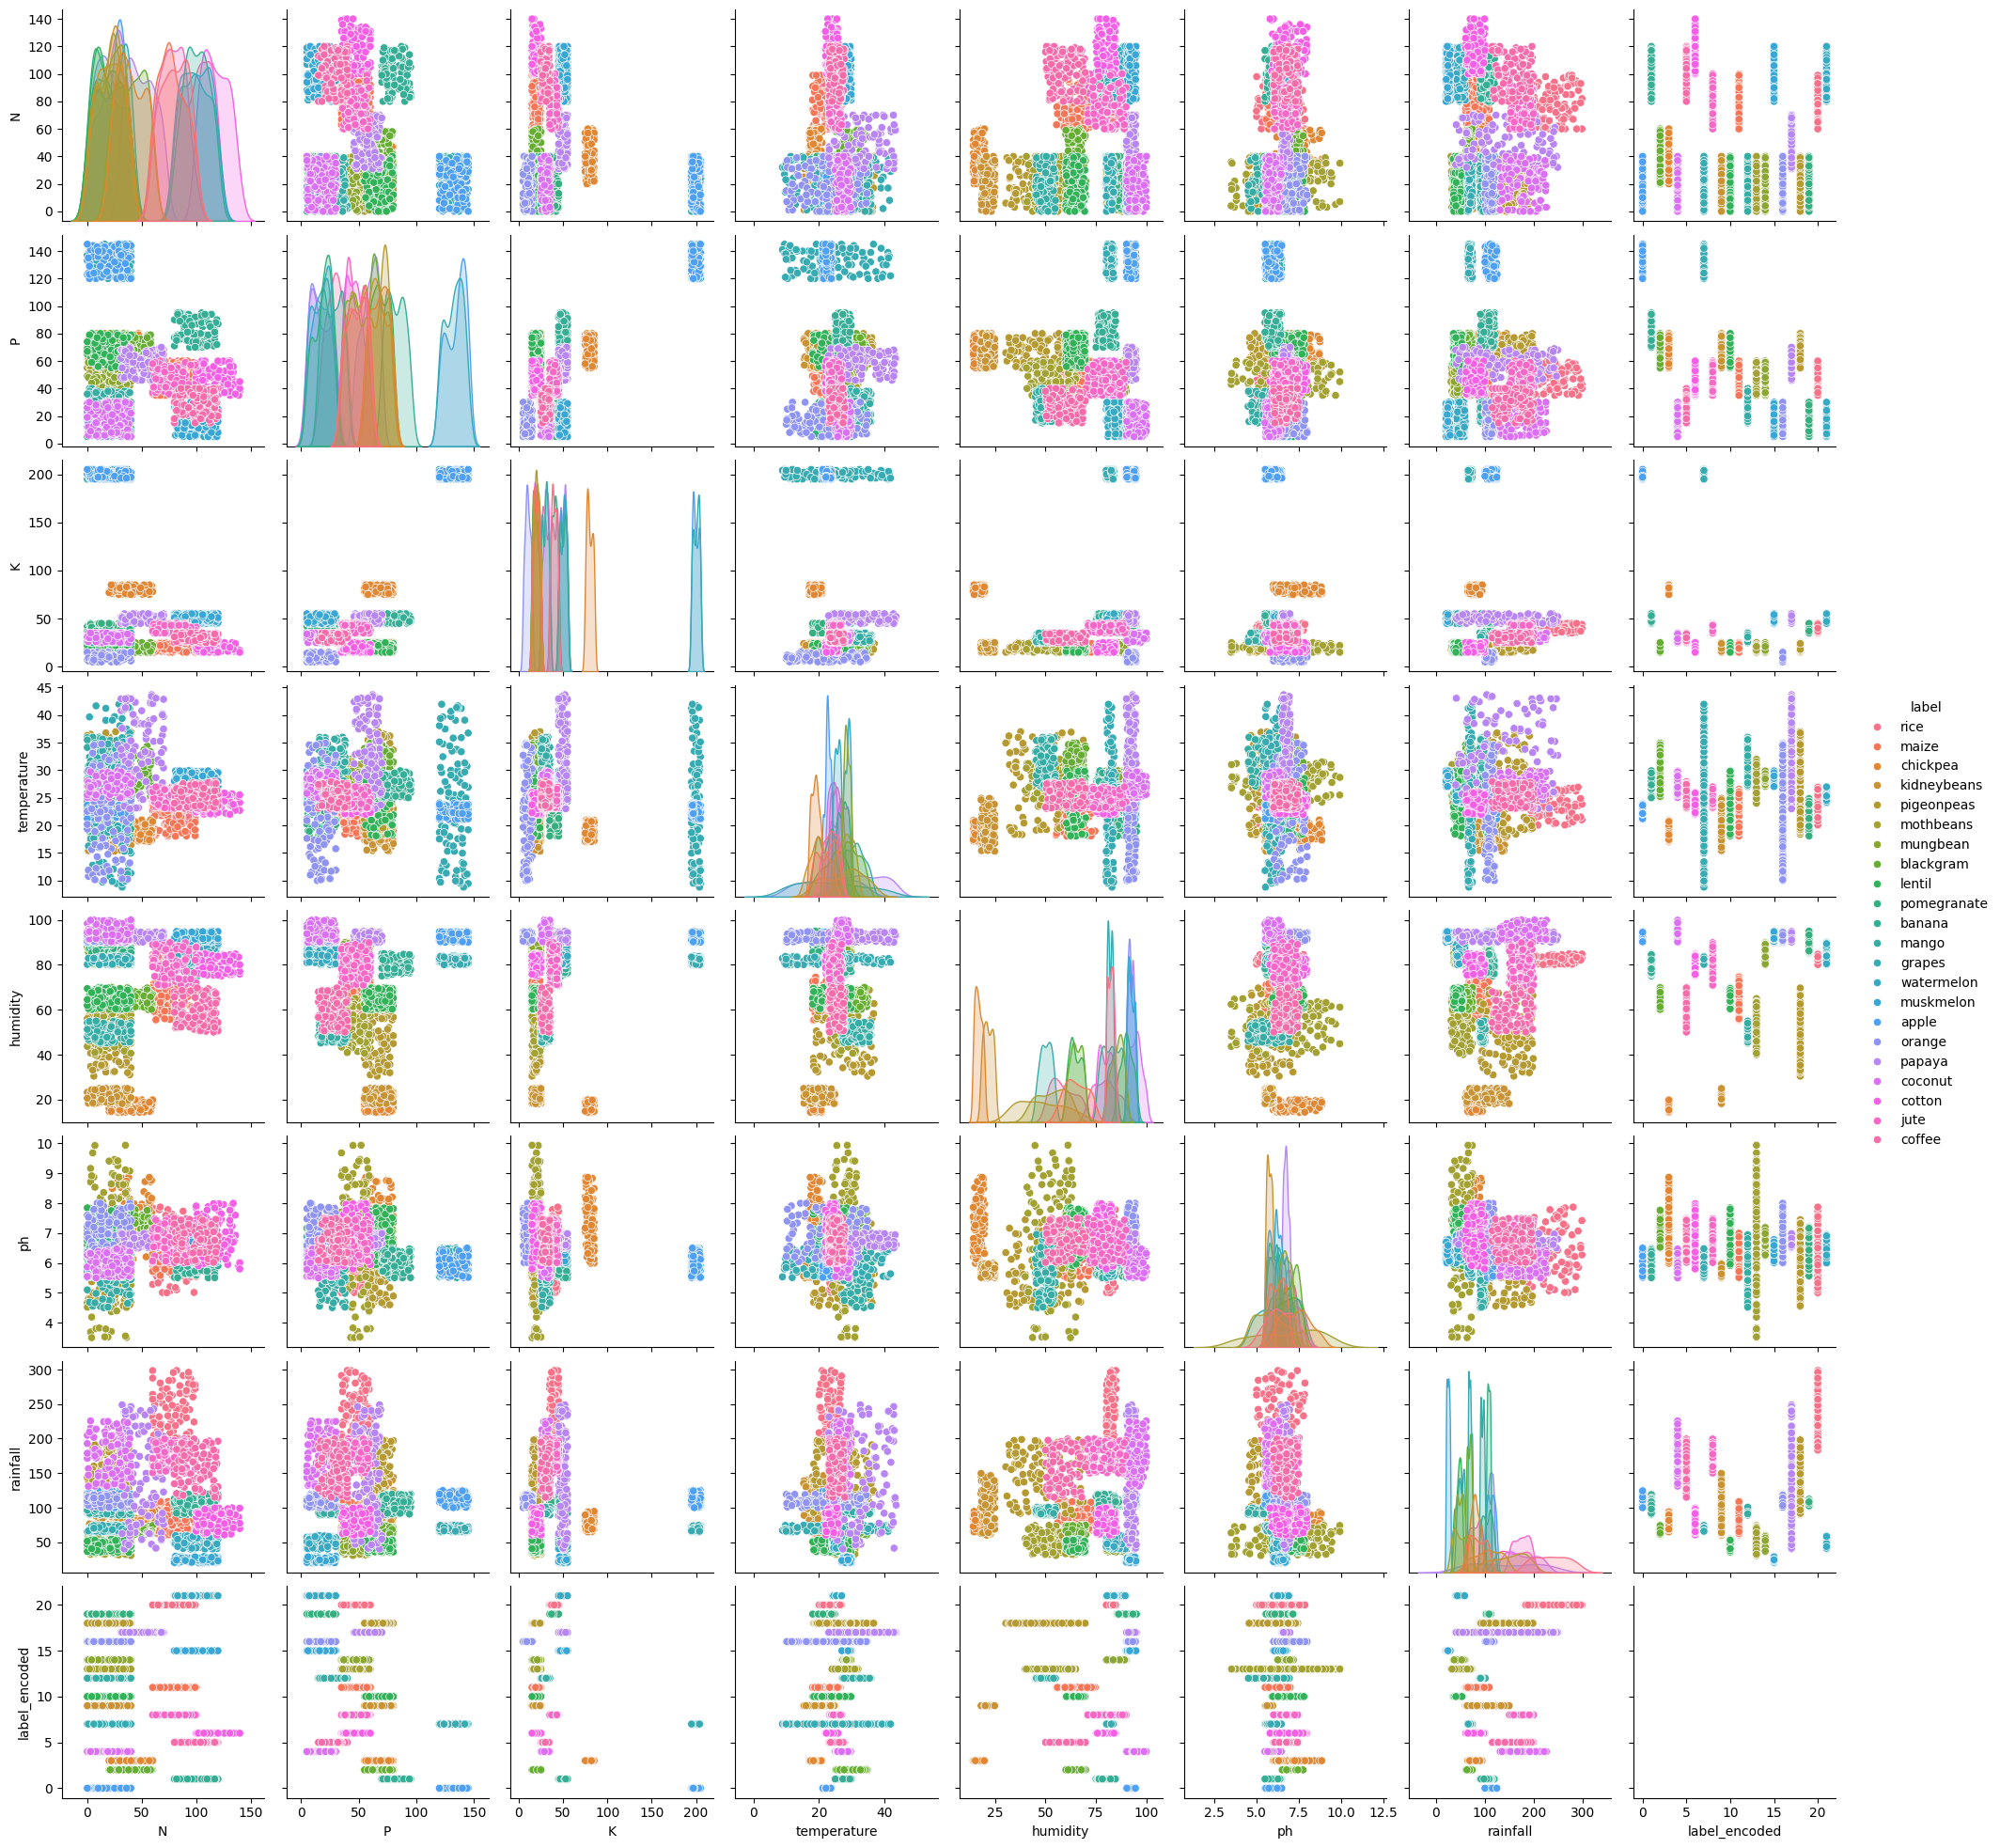

In [48]:
sns.pairplot(df3, hue='label')
plt.show()

In [49]:
import joblib

joblib.dump(model, 'crop_recommendation_model.pkl')

['crop_recommendation_model.pkl']

In [50]:
loaded_model = joblib.load('crop_recommendation_model.pkl')